In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from matplotlib.ticker import PercentFormatter


In [3]:
#baseline 5.0
#y10name='BrownDwarfs/baseline_v5_0_0_10yrs_RL2parallax_HEAL.npz'
#y02name='BrownDwarfsYear2/baseline_v5_0_0_10yrs_RL2parallax_night_lt_730_HEAL.npz'
#y10nameT2='BrownDwarfs/baseline_v5_0_0_10yrs_RT2parallax_HEAL.npz'
#y02nameT2='BrownDwarfsYear2/baseline_v5_0_0_10yrs_RT2parallax_night_lt_730_HEAL.npz'
# baseline 5.3 with tons of engineering time
y10name='BrownDwarfs/baseline_v5_3_0_10yrs_RL2parallax_HEAL.npz'
y02name='BrownDwarfsYear2/baseline_v5_3_0_10yrs_RL2parallax_night_lt_730_HEAL.npz'
y10nameT2='BrownDwarfs/baseline_v5_3_0_10yrs_RT2parallax_HEAL.npz'
y02nameT2='BrownDwarfsYear2/baseline_v5_3_0_10yrs_RT2parallax_night_lt_730_HEAL.npz'
#
#add year 1
y01name='BrownDwarfsYear2/baseline_v5_3_0_10yrs_RL2parallax_night_lt_730_HEAL.npz'
y01nameT2='BrownDwarfsYear1/baseline_v5_3_0_10yrs_RT2parallax_night_lt_365_HEAL.npz'
#
#
# in order to plot both 5.0 and 5.3
#  could also get the V1.7 from the old results (other github repo) but would be too busy for this plot.
v50_y10name='BrownDwarfs/baseline_v5_0_0_10yrs_RL2parallax_HEAL.npz'
v50_y02name='BrownDwarfsYear2/baseline_v5_0_0_10yrs_RL2parallax_night_lt_730_HEAL.npz'
v50_y10nameT2='BrownDwarfs/baseline_v5_0_0_10yrs_RT2parallax_HEAL.npz'
v50_y02nameT2='BrownDwarfsYear2/baseline_v5_0_0_10yrs_RT2parallax_night_lt_730_HEAL.npz'


In [4]:
yy10=np.load(y10name)
yy02 = np.load(y02name)
#
yy10T2=np.load(y10nameT2)
yy02T2 = np.load(y02nameT2)
#
yy01 =np.load(y01name)
yy01T2 = np.load(y01nameT2)

In [5]:
# load additional set from V5.0
v50_yy10=np.load(v50_y10name)
v50_yy02 = np.load(v50_y02name)
#
v50_yy10T2=np.load(v50_y10nameT2)
v50_yy02T2 = np.load(v50_y02nameT2)

In [6]:
#there are some NaNs in the arrays. experiment shows these are in the northern hemisphere and should be zero.
dd10=np.nan_to_num(yy10['metric_values'], nan=0.0)
dd02=np.nan_to_num(yy02['metric_values'], nan=0.0)
dd01=np.nan_to_num(yy01['metric_values'], nan=0.0)
dd10T2=np.nan_to_num(yy10T2['metric_values'], nan=0.0)
dd02T2=np.nan_to_num(yy02T2['metric_values'], nan=0.0)
dd01T2=np.nan_to_num(yy01T2['metric_values'], nan=0.0)
#
v50_dd10=np.nan_to_num(v50_yy10['metric_values'], nan=0.0)
v50_dd02=np.nan_to_num(v50_yy02['metric_values'], nan=0.0)
v50_dd10T2=np.nan_to_num(v50_yy10T2['metric_values'], nan=0.0)
v50_dd02T2=np.nan_to_num(v50_yy02T2['metric_values'], nan=0.0)
#

In [7]:
print(yy10.files)

['header', 'metric_values', 'mask', 'fill', 'slicer_init', 'slicer_name', 'slice_points', 'slicer_n_slice', 'slicer_shape']


In [8]:
yy10['metric_values']

array([0.00000000e+000, 9.10463678e-318, 0.00000000e+000, ...,
       4.91388986e+001, 4.79256354e+001, 4.68782095e+001], shape=(49152,))

In [9]:
#compute factor to normalize
norm = yy10['metric_values'].shape[0] 
# divide by 100 to get percentages later on
# not used
print(norm)
#this is 12 * 64**2

49152


In [10]:
bins = np.linspace(0, 200, 41)
bins2 = np.linspace(0, 220, 221)
bins

array([  0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,
        55.,  60.,  65.,  70.,  75.,  80.,  85.,  90.,  95., 100., 105.,
       110., 115., 120., 125., 130., 135., 140., 145., 150., 155., 160.,
       165., 170., 175., 180., 185., 190., 195., 200.])

In [11]:
w10=np.ones(len(yy10['metric_values'])) / len(yy10['metric_values'])
w02=np.ones(len(yy02['metric_values'])) / len(yy02['metric_values'])
print(w10)
print(w02)
#note these are expected to be the same!

[2.03450521e-05 2.03450521e-05 2.03450521e-05 ... 2.03450521e-05
 2.03450521e-05 2.03450521e-05]
[2.03450521e-05 2.03450521e-05 2.03450521e-05 ... 2.03450521e-05
 2.03450521e-05 2.03450521e-05]


In [12]:
wfd_nominal = 18000.0/41253



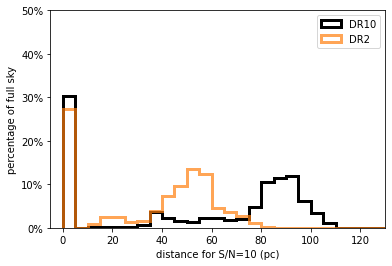

In [13]:
#plt.hist(yy10['metric_values'], histtype='stepfilled', bins=30, alpha=0.3, linewidth=4, label='DR10', color='blue',
#         edgecolor='k', weights=w10)
#plt.hist(yy10['metric_values'], histtype='step', bins=bins, alpha=1, linewidth=3, color='k', label='DR10',weights=w10)
#plt.hist(yy02['metric_values'], histtype='step', bins=bins, alpha=0.7, linewidth=3, label='DR2', color='C1', weights=w02)
plt.hist(dd10, histtype='step', bins=bins, alpha=1, linewidth=3, color='k', label='DR10',weights=w10)
plt.hist(dd02, histtype='step', bins=bins, alpha=0.7, linewidth=3, label='DR2', color='C1', weights=w02)
plt.xlim(-5,130)
plt.ylim(0,0.5)  #note this is the original units, fractions
plt.legend()
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.xlabel('distance for S/N=10 (pc)')
plt.ylabel('percentage of full sky')
plt.savefig('test.png')

In [14]:
import healpy as hp


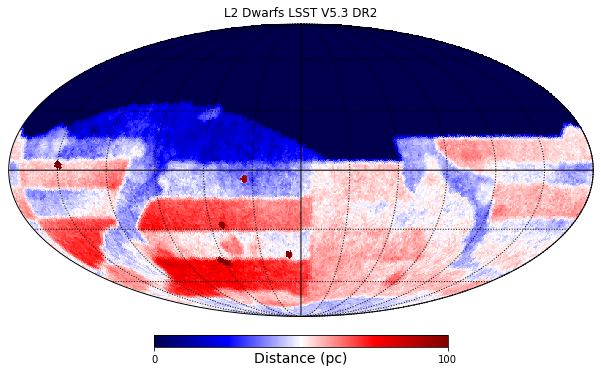

In [15]:
# same color map as Rubin Observaory uses: cmap="viridis"
#  can also try a diverging color map like seismic
#hp.mollview(yy02['metric_values'], title="LSST V5.3 DR2", unit="Distance (pc)", cmap="seismic", min=0, max=100)
hp.mollview(dd02, title="L2 Dwarfs LSST V5.3 DR2", unit="Distance (pc)", cmap="seismic", min=0, max=100)
hp.graticule()  # Optional: adds grid lines for latitude/longitude
plt.show()

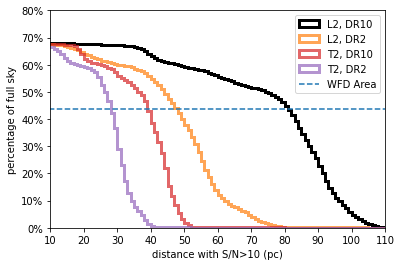

In [16]:
#plt.hist(yy10['metric_values'], histtype='stepfilled', bins=30, alpha=0.3, linewidth=4, label='DR10', color='blue',
#         edgecolor='k', weights=w10)
plt.hist(yy10['metric_values'], histtype='step', bins=bins2, alpha=1, linewidth=3, color='k', label='L2, DR10', cumulative=-1, weights=w10)
plt.hist(yy02['metric_values'], histtype='step', bins=bins2, alpha=0.7, linewidth=3, label='L2, DR2', color='C1', cumulative=-1, weights=w02)
plt.hist(yy10T2['metric_values'], histtype='step', bins=bins2, alpha=0.7, linewidth=3, color='C3', label='T2, DR10', cumulative=-1, weights=w10)
plt.hist(yy02T2['metric_values'], histtype='step', bins=bins2, alpha=0.7, linewidth=3, label='T2, DR2', color='C4', cumulative=-1, weights=w02)
plt.plot([0,200],np.array([1,1])*wfd_nominal,'--',label='WFD Area')
plt.xlim(110,10)
plt.ylim(0,0.8)  #note this is the original units, fractions
plt.legend(loc='upper right')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.xlabel('distance with S/N>10 (pc)')
plt.ylabel('percentage of full sky')
plt.xticks(np.arange(10, 111, step=10))
plt.gca().invert_xaxis()
#plt.savefig('test_cumulative.pdf')

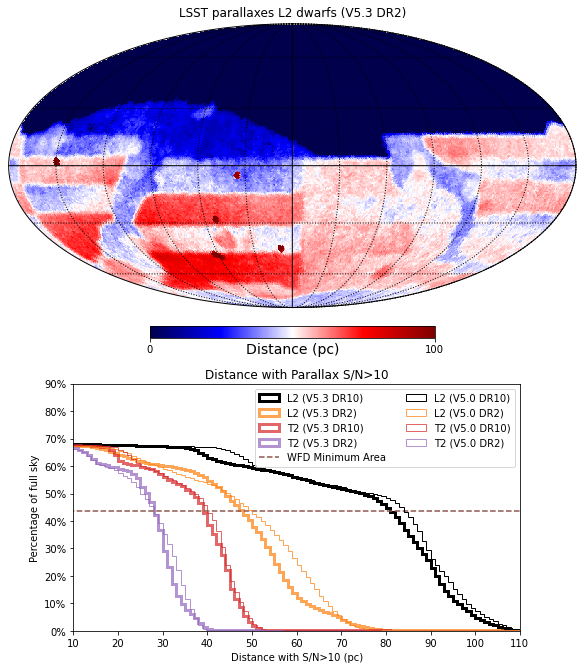

In [17]:
# use version where nan set to 0
fig = plt.figure(figsize=(8, 10))
hp.mollview(dd02, title="LSST parallaxes L2 dwarfs (V5.3 DR2)", unit="Distance (pc)", fig=fig, sub=(2,1,1), 
            cmap="seismic", min=0, max=100)
hp.graticule()  # Optional: adds grid lines for latitude/longitude
#
# bottom:
ax_hist = fig.add_subplot(2, 1, 2)
ax_hist.hist(dd10, histtype='step', bins=bins2, alpha=1, linewidth=3, cumulative=-1, 
             color='k', label='L2 (V5.3 DR10)',weights=w10)
ax_hist.hist(dd02, histtype='step', bins=bins2, alpha=0.7, linewidth=3, cumulative=-1,
             label='L2 (V5.3 DR2)', color='C1', weights=w02)
ax_hist.hist(dd10T2, histtype='step', bins=bins2, alpha=0.7, linewidth=3, cumulative=-1,
             label='T2 (V5.3 DR10)', color='C3', weights=w02)
ax_hist.hist(dd02T2, histtype='step', bins=bins2, alpha=0.7, linewidth=3, cumulative=-1,
             label='T2 (V5.3 DR2)', color='C4', weights=w02)
# legend works better if we plot WFD here
ax_hist.plot([0,200],np.array([1,1])*wfd_nominal,'--',color='C5',label='WFD Minimum Area')
#
ax_hist.hist(v50_dd10, histtype='step', bins=bins2, alpha=1, linewidth=1, cumulative=-1, 
             color='k', label='L2 (V5.0 DR10)',weights=w10)
ax_hist.hist(v50_dd02, histtype='step', bins=bins2, alpha=0.7, linewidth=1, cumulative=-1,
             label='L2 (V5.0 DR2)', color='C1', weights=w02)
ax_hist.hist(v50_dd10T2, histtype='step', bins=bins2, alpha=0.7, linewidth=1, cumulative=-1,
             label='T2 (V5.0 DR10)', color='C3', weights=w02)
ax_hist.hist(v50_dd02T2, histtype='step', bins=bins2, alpha=0.7, linewidth=1, cumulative=-1,
             label='T2 (V5.0 DR2)', color='C4', weights=w02)
ax_hist.set_xlim(110,10)
ax_hist.set_ylim(0,0.9)
ax_hist.set_xticks(np.arange(10, 111, step=10))
ax_hist.invert_xaxis()
ax_hist.legend(loc='upper right',ncols=2)
ax_hist.set_title("Distance with Parallax S/N>10")
ax_hist.set_ylabel("Percentage of full sky")
ax_hist.set_xlabel("Distance with S/N>10 (pc)")
ax_hist.yaxis.set_major_formatter(PercentFormatter(1))
#plt.savefig('plot-figure1.png')

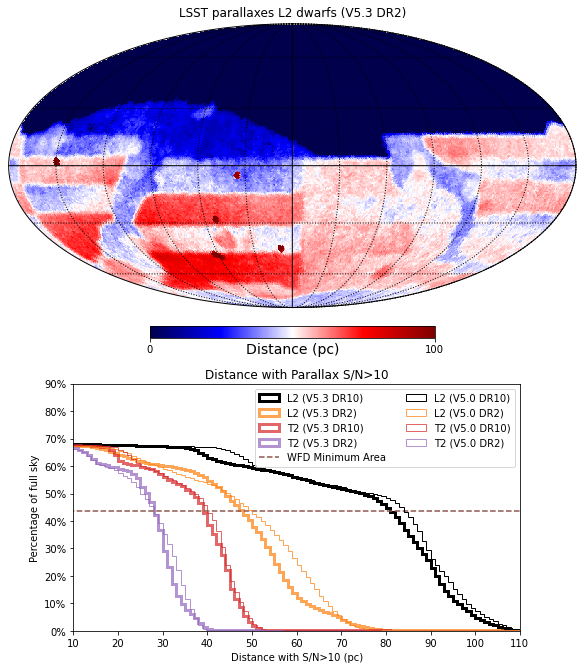

In [18]:
#original metric values
fig = plt.figure(figsize=(8, 10))
hp.mollview(yy02['metric_values'], title="LSST parallaxes L2 dwarfs (V5.3 DR2)", unit="Distance (pc)", fig=fig, sub=(2,1,1), 
            cmap="seismic", min=0, max=100)
hp.graticule()  # Optional: adds grid lines for latitude/longitude
#
# bottom:
ax_hist = fig.add_subplot(2, 1, 2)
ax_hist.hist(yy10['metric_values'], histtype='step', bins=bins2, alpha=1, linewidth=3, cumulative=-1, 
             color='k', label='L2 (V5.3 DR10)',weights=w10)
ax_hist.hist(yy02['metric_values'], histtype='step', bins=bins2, alpha=0.7, linewidth=3, cumulative=-1,
             label='L2 (V5.3 DR2)', color='C1', weights=w02)
ax_hist.hist(yy10T2['metric_values'], histtype='step', bins=bins2, alpha=0.7, linewidth=3, cumulative=-1,
             label='T2 (V5.3 DR10)', color='C3', weights=w02)
ax_hist.hist(yy02T2['metric_values'], histtype='step', bins=bins2, alpha=0.7, linewidth=3, cumulative=-1,
             label='T2 (V5.3 DR2)', color='C4', weights=w02)
ax_hist.plot([0,200],np.array([1,1])*wfd_nominal,'--',color='C5',label='WFD Minimum Area')
ax_hist.hist(v50_yy10['metric_values'], histtype='step', bins=bins2, alpha=1, linewidth=1, cumulative=-1, 
             color='k', label='L2 (V5.0 DR10)',weights=w10)
ax_hist.hist(v50_yy02['metric_values'], histtype='step', bins=bins2, alpha=0.7, linewidth=1, cumulative=-1,
             label='L2 (V5.0 DR2)', color='C1', weights=w02)
ax_hist.hist(v50_yy10T2['metric_values'], histtype='step', bins=bins2, alpha=0.7, linewidth=1, cumulative=-1,
             label='T2 (V5.0 DR10)', color='C3', weights=w02)
ax_hist.hist(v50_yy02T2['metric_values'], histtype='step', bins=bins2, alpha=0.7, linewidth=1, cumulative=-1,
             label='T2 (V5.0 DR2)', color='C4', weights=w02)
ax_hist.set_xlim(110,10)
ax_hist.set_ylim(0,0.9)
ax_hist.set_xticks(np.arange(10, 111, step=10))
ax_hist.invert_xaxis()
ax_hist.legend(loc='upper right',ncols=2)
ax_hist.set_title("Distance with Parallax S/N>10")
ax_hist.set_ylabel("Percentage of full sky")
ax_hist.set_xlabel("Distance with S/N>10 (pc)")
ax_hist.yaxis.set_major_formatter(PercentFormatter(1))
#plt.savefig('plot-figure1.png')

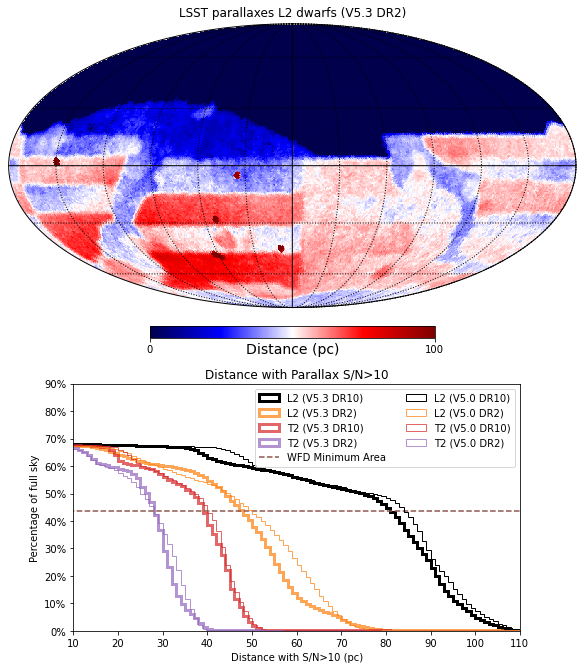

In [19]:
#original metric values
fig = plt.figure(figsize=(8, 10))
hp.mollview(yy02['metric_values'], title="LSST parallaxes L2 dwarfs (V5.3 DR2)", unit="Distance (pc)", fig=fig, sub=(2,1,1), 
            cmap="seismic", min=0, max=100)
hp.graticule()  # Optional: adds grid lines for latitude/longitude
#
# bottom:
ax_hist = fig.add_subplot(2, 1, 2)
ax_hist.hist(yy10['metric_values'], histtype='step', bins=bins2, alpha=1, linewidth=3, cumulative=-1, 
             color='k', label='L2 (V5.3 DR10)',weights=w10)
ax_hist.hist(yy02['metric_values'], histtype='step', bins=bins2, alpha=0.7, linewidth=3, cumulative=-1,
             label='L2 (V5.3 DR2)', color='C1', weights=w02)
ax_hist.hist(yy10T2['metric_values'], histtype='step', bins=bins2, alpha=0.7, linewidth=3, cumulative=-1,
             label='T2 (V5.3 DR10)', color='C3', weights=w02)
ax_hist.hist(yy02T2['metric_values'], histtype='step', bins=bins2, alpha=0.7, linewidth=3, cumulative=-1,
             label='T2 (V5.3 DR2)', color='C4', weights=w02)
ax_hist.plot([0,200],np.array([1,1])*wfd_nominal,'--',color='C5',label='WFD Minimum Area')
ax_hist.hist(v50_yy10['metric_values'], histtype='step', bins=bins2, alpha=1, linewidth=1, cumulative=-1, 
             color='k', label='L2 (V5.0 DR10)',weights=w10)
ax_hist.hist(v50_yy02['metric_values'], histtype='step', bins=bins2, alpha=0.7, linewidth=1, cumulative=-1,
             label='L2 (V5.0 DR2)', color='C1', weights=w02)
ax_hist.hist(v50_yy10T2['metric_values'], histtype='step', bins=bins2, alpha=0.7, linewidth=1, cumulative=-1,
             label='T2 (V5.0 DR10)', color='C3', weights=w02)
ax_hist.hist(v50_yy02T2['metric_values'], histtype='step', bins=bins2, alpha=0.7, linewidth=1, cumulative=-1,
             label='T2 (V5.0 DR2)', color='C4', weights=w02)
ax_hist.set_xlim(110,10)
ax_hist.set_ylim(0,0.9)
ax_hist.set_xticks(np.arange(10, 111, step=10))
ax_hist.invert_xaxis()
ax_hist.legend(loc='upper right',ncols=2)
ax_hist.set_title("Distance with Parallax S/N>10")
ax_hist.set_ylabel("Percentage of full sky")
ax_hist.set_xlabel("Distance with S/N>10 (pc)")
ax_hist.yaxis.set_major_formatter(PercentFormatter(1))
#plt.savefig('plot-figure1.png')

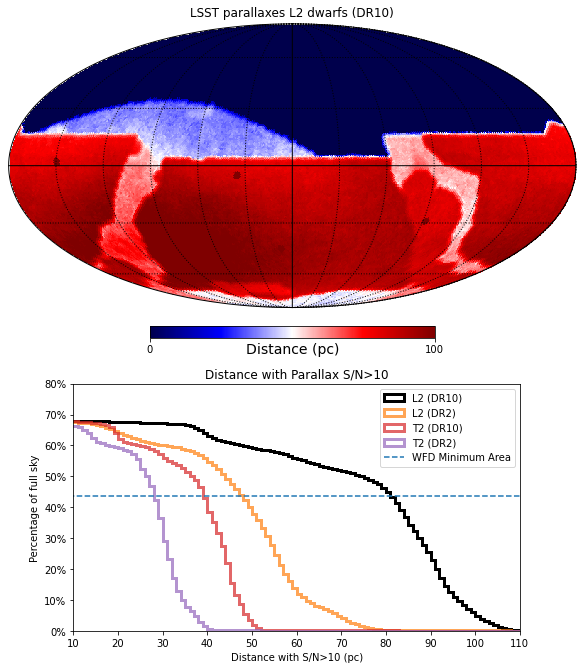

In [20]:
# nan to 0 version
fig = plt.figure(figsize=(8, 10))
hp.mollview(dd10, title="LSST parallaxes L2 dwarfs (DR10)", unit="Distance (pc)", fig=fig, sub=(2,1,1), 
            cmap="seismic", min=0, max=100)
hp.graticule()  # Optional: adds grid lines for latitude/longitude
#
# bottom:
ax_hist = fig.add_subplot(2, 1, 2)
ax_hist.hist(dd10, histtype='step', bins=bins2, alpha=1, linewidth=3, cumulative=-1, 
             color='k', label='L2 (DR10)',weights=w10)
ax_hist.hist(dd02, histtype='step', bins=bins2, alpha=0.7, linewidth=3, cumulative=-1,
             label='L2 (DR2)', color='C1', weights=w02)
ax_hist.hist(dd10T2, histtype='step', bins=bins2, alpha=0.7, linewidth=3, cumulative=-1,
             label='T2 (DR10)', color='C3', weights=w02)
ax_hist.hist(dd02T2, histtype='step', bins=bins2, alpha=0.7, linewidth=3, cumulative=-1,
             label='T2 (DR2)', color='C4', weights=w02)
ax_hist.plot([0,200],np.array([1,1])*wfd_nominal,'--',label='WFD Minimum Area')
ax_hist.set_xlim(110,10)
ax_hist.set_ylim(0,0.8)
ax_hist.set_xticks(np.arange(10, 111, step=10))
ax_hist.invert_xaxis()
ax_hist.legend(loc='upper right')
ax_hist.set_title("Distance with Parallax S/N>10")
ax_hist.set_ylabel("Percentage of full sky")
ax_hist.set_xlabel("Distance with S/N>10 (pc)")
ax_hist.yaxis.set_major_formatter(PercentFormatter(1))

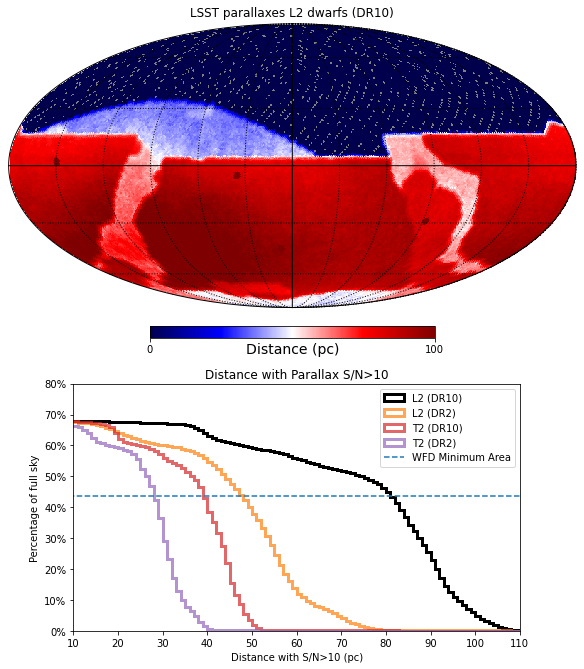

In [21]:
# original metric array.  map is 10 year version
fig = plt.figure(figsize=(8, 10))
hp.mollview(yy10['metric_values'], title="LSST parallaxes L2 dwarfs (DR10)", unit="Distance (pc)", fig=fig, sub=(2,1,1), 
            cmap="seismic", min=0, max=100)
hp.graticule()  # Optional: adds grid lines for latitude/longitude
#
# bottom:
ax_hist = fig.add_subplot(2, 1, 2)
ax_hist.hist(yy10['metric_values'], histtype='step', bins=bins2, alpha=1, linewidth=3, cumulative=-1, 
             color='k', label='L2 (DR10)',weights=w10)
ax_hist.hist(yy02['metric_values'], histtype='step', bins=bins2, alpha=0.7, linewidth=3, cumulative=-1,
             label='L2 (DR2)', color='C1', weights=w02)
ax_hist.hist(yy10T2['metric_values'], histtype='step', bins=bins2, alpha=0.7, linewidth=3, cumulative=-1,
             label='T2 (DR10)', color='C3', weights=w02)
ax_hist.hist(yy02T2['metric_values'], histtype='step', bins=bins2, alpha=0.7, linewidth=3, cumulative=-1,
             label='T2 (DR2)', color='C4', weights=w02)
ax_hist.plot([0,200],np.array([1,1])*wfd_nominal,'--',label='WFD Minimum Area')
ax_hist.set_xlim(110,10)
ax_hist.set_ylim(0,0.8)
ax_hist.set_xticks(np.arange(10, 111, step=10))
ax_hist.invert_xaxis()
ax_hist.legend(loc='upper right')
ax_hist.set_title("Distance with Parallax S/N>10")
ax_hist.set_ylabel("Percentage of full sky")
ax_hist.set_xlabel("Distance with S/N>10 (pc)")
ax_hist.yaxis.set_major_formatter(PercentFormatter(1))

In [22]:
#above plots are based on histograms due to initial approach.
# However, it may be better to directly plot the empirical cumulative distribution function.


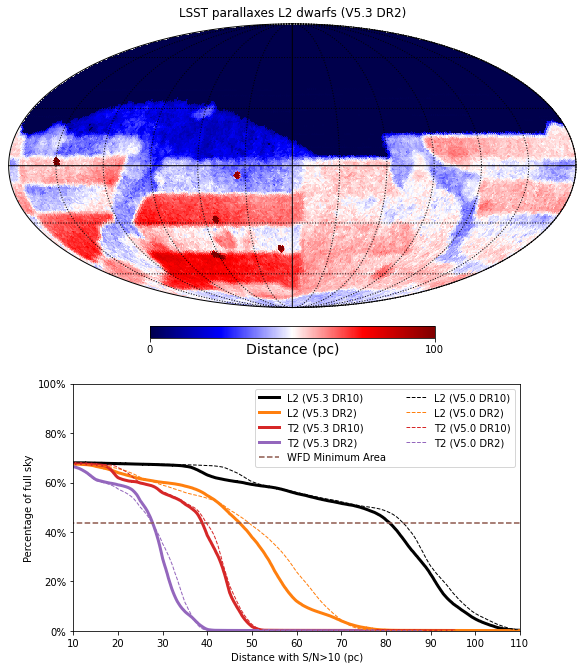

In [23]:
fig = plt.figure(figsize=(8, 10))
hp.mollview(dd02, title="LSST parallaxes L2 dwarfs (V5.3 DR2)", unit="Distance (pc)", fig=fig, sub=(2,1,1), 
            cmap="seismic", min=0, max=100)
hp.graticule()  # Optional: adds grid lines for latitude/longitude
#
# bottom:
ax_hist = fig.add_subplot(2, 1, 2)
ax_hist.ecdf(dd10, label='L2 (V5.3 DR10)', complementary=True, linewidth=3, color='k')
ax_hist.ecdf(dd02, label='L2 (V5.3 DR2)', complementary=True, linewidth=3, color='C1')
ax_hist.ecdf(dd10T2, label='T2 (V5.3 DR10)', complementary=True, linewidth=3, color='C3')
ax_hist.ecdf(dd02T2, label='T2 (V5.3 DR2)', complementary=True, linewidth=3, color='C4')
ax_hist.set_xlim(110,10)
# plot WFD here for legend
ax_hist.plot([0,200],np.array([1,1])*wfd_nominal,'--',color='C5',label='WFD Minimum Area')
#
ax_hist.ecdf(v50_dd10, label='L2 (V5.0 DR10)', complementary=True, linewidth=1, color='k', linestyle='dashed')
ax_hist.ecdf(v50_dd02, label='L2 (V5.0 DR2)', complementary=True, linewidth=1, color='C1', linestyle='dashed')
ax_hist.ecdf(v50_dd10T2, label='T2 (V5.0 DR10)', complementary=True, linewidth=1, color='C3', linestyle='dashed')
ax_hist.ecdf(v50_dd02T2, label='T2 (V5.0 DR2)', complementary=True, linewidth=1, color='C4', linestyle='dashed')
#
#ax_hist.set_ylim(0,0.9)
ax_hist.set_xticks(np.arange(10, 111, step=10))
ax_hist.invert_xaxis()
ax_hist.legend(loc='upper right',ncols=2)
#ax_hist.set_title("Cumulative Distributions")
ax_hist.set_ylabel("Percentage of full sky")
ax_hist.set_xlabel("Distance with S/N>10 (pc)")
ax_hist.yaxis.set_major_formatter(PercentFormatter(1))
plt.savefig('plot-figure1.png')

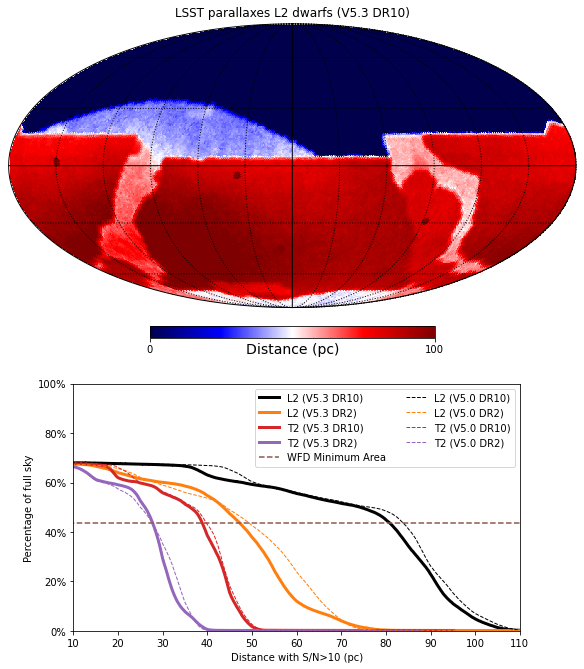

In [24]:
fig = plt.figure(figsize=(8, 10))
hp.mollview(dd10, title="LSST parallaxes L2 dwarfs (V5.3 DR10)", unit="Distance (pc)", fig=fig, sub=(2,1,1), 
            cmap="seismic", min=0, max=100)
hp.graticule()  # Optional: adds grid lines for latitude/longitude
#
# bottom:
ax_hist = fig.add_subplot(2, 1, 2)
ax_hist.ecdf(dd10, label='L2 (V5.3 DR10)', complementary=True, linewidth=3, color='k')
ax_hist.ecdf(dd02, label='L2 (V5.3 DR2)', complementary=True, linewidth=3, color='C1')
ax_hist.ecdf(dd10T2, label='T2 (V5.3 DR10)', complementary=True, linewidth=3, color='C3')
ax_hist.ecdf(dd02T2, label='T2 (V5.3 DR2)', complementary=True, linewidth=3, color='C4')
ax_hist.set_xlim(110,10)
# plot WFD here for legend
ax_hist.plot([0,200],np.array([1,1])*wfd_nominal,'--',color='C5',label='WFD Minimum Area')
#
ax_hist.ecdf(v50_dd10, label='L2 (V5.0 DR10)', complementary=True, linewidth=1, color='k', linestyle='dashed')
ax_hist.ecdf(v50_dd02, label='L2 (V5.0 DR2)', complementary=True, linewidth=1, color='C1', linestyle='dashed')
ax_hist.ecdf(v50_dd10T2, label='T2 (V5.0 DR10)', complementary=True, linewidth=1, color='C3', linestyle='dashed')
ax_hist.ecdf(v50_dd02T2, label='T2 (V5.0 DR2)', complementary=True, linewidth=1, color='C4', linestyle='dashed')
#
#ax_hist.set_ylim(0,0.9)
ax_hist.set_xticks(np.arange(10, 111, step=10))
ax_hist.invert_xaxis()
ax_hist.legend(loc='upper right',ncols=2)
#ax_hist.set_title("Cumulative Distributions")
ax_hist.set_ylabel("Percentage of full sky")
ax_hist.set_xlabel("Distance with S/N>10 (pc)")
ax_hist.yaxis.set_major_formatter(PercentFormatter(1))
plt.savefig('plot-figure1-10year.png')

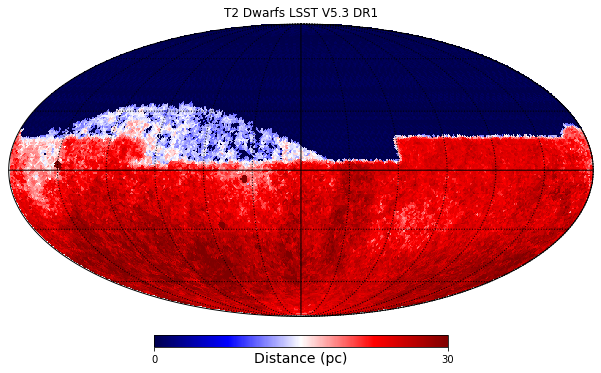

In [30]:
# same color map as Rubin Observaory uses: cmap="viridis"
#  can also try a diverging color map like seismic
#hp.mollview(yy02['metric_values'], title="LSST V5.3 DR2", unit="Distance (pc)", cmap="seismic", min=0, max=100)
hp.mollview(dd01T2, title="T2 Dwarfs LSST V5.3 DR1", unit="Distance (pc)", cmap="seismic", min=0, max=30)
hp.graticule()  # Optional: adds grid lines for latitude/longitude
#plt.show()
plt.savefig('plot-T2-year1.png')

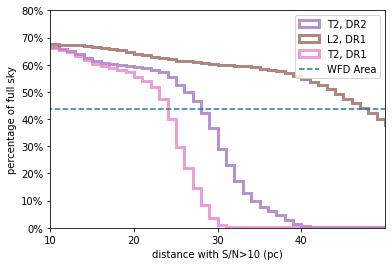

In [40]:
#plt.hist(yy10['metric_values'], histtype='stepfilled', bins=30, alpha=0.3, linewidth=4, label='DR10', color='blue',
#         edgecolor='k', weights=w10)
#
#plt.hist(dd02, histtype='step', bins=bins2, alpha=0.7, linewidth=3, label='L2, DR2', color='C1', cumulative=-1, weights=w02)
plt.hist(dd02T2, histtype='step', bins=bins2, alpha=0.7, linewidth=3, label='T2, DR2', color='C4', cumulative=-1, weights=w02)
plt.hist(dd01, histtype='step', bins=bins2, alpha=0.7, linewidth=3, label='L2, DR1', color='C5', cumulative=-1, weights=w02)
plt.hist(dd01T2, histtype='step', bins=bins2, alpha=0.7, linewidth=3, label='T2, DR1', color='C6', cumulative=-1, weights=w02)
plt.plot([0,200],np.array([1,1])*wfd_nominal,'--',label='WFD Area')
plt.xlim(50,10)
plt.ylim(0,0.8)  #note this is the original units, fractions
plt.legend(loc='upper right')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.xlabel('distance with S/N>10 (pc)')
plt.ylabel('percentage of full sky')
plt.xticks(np.arange(10, 50, step=10))
plt.gca().invert_xaxis()
plt.savefig('plot_DR1.png')